In [23]:
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import anndata as ad
import scanpy as sc
from scipy import stats
import statsmodels.formula.api as smf

import cellspec as spc

%matplotlib inline

In [24]:
# sns.set_style("white", {"axes.facecolor": (0, 0, 0, 0)}) 
plt.style.use("dark_background")

# Load Data

In [ ]:
adata = spc.pp.load_vcf('../data/K562_mut_accumulation/K562_mut_accumulation_joint.vcf.gz')
adata

Loading VCF: 1840845 sites [00:56, 33958.08 sites/s]

In [ ]:
obs = {
    "AAVS_Clone_4_P1":["WT","C4",1],
    "AAVS_Clone_4_P2":["WT","C4",2],
    "AAVS_Clone_4_P3":["WT","C4",3],
    "AAVS_Clone_5_P1":["WT","C5",1],
    "AAVS_Clone_5_P2":["WT","C5",2],
    "AAVS_Clone_5_P3":["WT","C5",3],
    "AAVS_Clone_6_P1":["WT","C6",1],
    "AAVS_Clone_6_P2":["WT","C6",2],
    "AAVS_Clone_6_P3":["WT","C6",3],
    "PolE_Clone_4_P1":["P286R","C4",1],
    "PolE_Clone_4_P2":["P286R","C4",2],
    "PolE_Clone_4_P3":["P286R","C4",3],
    "PolE_Clone_5_P1":["P286R","C5",1],
    "PolE_Clone_5_P2":["P286R","C5",2],
    "PolE_Clone_6_P1":["P286R","C6",1],
    "PolE_Clone_6_P2":["P286R","C6",2],
    "PolE_Clone_6_P3":["P286R","C6",3],
}
adata.obs = pd.DataFrame.from_dict(obs, orient='index', columns=['Mutation','Replicate','Split'])

In [ ]:
# adata.write_h5ad('../results/')

In [ ]:
## Filter out non snps
spc.pp.filter_to_snps(adata, inplace=True)

In [ ]:
# Filter out sites without sufficient coverage in all samples
# spc.pp.filter_by_coverage(adata, min_depth=10)

In [ ]:
spc.pp.annotate_contexts(adata, fasta_path='/shared/biodata/reference/GATK/hg38/Homo_sapiens_assembly38.fasta')
adata.var

## QC checks

In [ ]:
adata.var['tot_depth_bulk'] = np.ravel(adata.layers['DP'].sum(axis=0))

In [ ]:
sns.set_theme(style="ticks")
f, ax = plt.subplots(figsize=(7, 5))
sns.despine(f)
sns.histplot(adata.var, x='tot_depth_bulk', 
             alpha=0.5,
             color = '#317EC2',
             edgecolor=".3",
             linewidth=.5,
             ax=ax,
             log_scale=True,
             bins=10
            )
ax.set_yscale('log')
plt.xlabel("Depth accross samples", fontsize=12)
plt.ylabel("Count of Sites", fontsize=12)


In [ ]:
spc.tl.compute_bulk_vaf(adata,
                        target_dp=100
                       )

In [ ]:
sns.set_theme(style="ticks")
f, ax = plt.subplots(figsize=(7, 5))
sns.despine(f)
sns.histplot(adata.var, x='bulk_vaf', 
             alpha=0.5,
             color = '#317EC2',
             edgecolor=".3",
             linewidth=.5,
             ax=ax,
             # log_scale=True,
             bins=10
            )
ax.set_yscale('log')
plt.xlabel("VAF in Bulk", fontsize=12)
plt.ylabel("Count of Sites", fontsize=12)

## Save adata for fast reloading:

In [ ]:
adata.write_h5ad('../results/K562_mut_accumulation/K562_mut_accumulation.h5ad')

# Load adata from h5ad

In [3]:
adata = ad.read_h5ad('../results/K562_mut_accumulation/K562_mut_accumulation.h5ad')

# Filter to Low VAF (somatic) SNPs

In [4]:
adata = adata[:,adata.var['bulk_vaf']<0.4].copy()

In [5]:
adata.obs['snp_count'] = np.ravel((adata.X>0).sum(axis=1))

In [6]:
adata.obs['snp_count'].mean()

np.float64(829280.0588235294)

# Mutation Spectrum

In [14]:
spc.tl.compute_spectrum(adata)

Computing spectrum (key='spectrum'): 100%|██████████| 17/17 [00:08<00:00,  1.92cell/s]


,ACA>AAA,ACC>AAC,ACG>AAG,ACT>AAT,CCA>CAA,CCC>CAC,CCG>CAG,CCT>CAT,GCA>GAA,GCC>GAC,...,CTG>CGG,CTT>CGT,GTA>GGA,GTC>GGC,GTG>GGG,GTT>GGT,TTA>TGA,TTC>TGC,TTG>TGG,TTT>TGT
AAVS_Clone_4_P1,9124,6246,3024,5424,7791,6114,3070,6579,7030,4532,...,3690,3383,2804,2433,4523,4305,3830,4031,5450,7958
AAVS_Clone_4_P2,9953,6612,3183,5768,8023,6500,3184,7346,7337,4655,...,3740,3560,2856,2520,4679,4562,4021,4226,5571,8428
AAVS_Clone_4_P3,10403,6720,3285,5880,8226,6578,3281,7243,7615,4831,...,3847,3580,2969,2558,4740,4719,4239,4254,5738,8780
AAVS_Clone_5_P1,9691,6345,3108,5594,7544,5747,2899,6403,7103,4463,...,3551,3376,2800,2389,4472,4385,3834,4043,5378,8018
AAVS_Clone_5_P2,10530,6514,3061,5858,7883,6285,3087,7193,7385,4676,...,3615,3438,2760,2433,4542,4417,4028,4138,5575,8619
AAVS_Clone_5_P3,9196,6071,2908,5340,7619,5902,2999,6504,6978,4405,...,3576,3272,2684,2382,4394,4228,3766,3917,5357,7888
AAVS_Clone_6_P1,10183,6619,3253,5759,7979,5987,3128,6754,7521,4711,...,3765,3569,2881,2571,4672,4661,4044,4305,5730,8687
AAVS_Clone_6_P2,10043,6743,3332,5833,8164,6340,3259,6996,7522,4839,...,3815,3653,2975,2542,4701,4598,4097,4300,5726,8757
AAVS_Clone_6_P3,10231,6811,3273,5793,8049,6381,3178,6960,7531,4794,...,3860,3688,2944,2611,4697,4731,4156,4310,5749,8907
PolE_Clone_4_P1,9780,6414,3165,6126,7767,5827,2915,7628,7146,4583,...,3631,4115,2831,2526,4442,4455,4487,4266,5446,12680


/fh/fast/srivatsan_s/grp/SrivatsanLab/Dustin/cellspec/src/cellspec/pl/spectrum.py:248: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group_name, group_indices in adata.obs.groupby(groupby).groups.items():


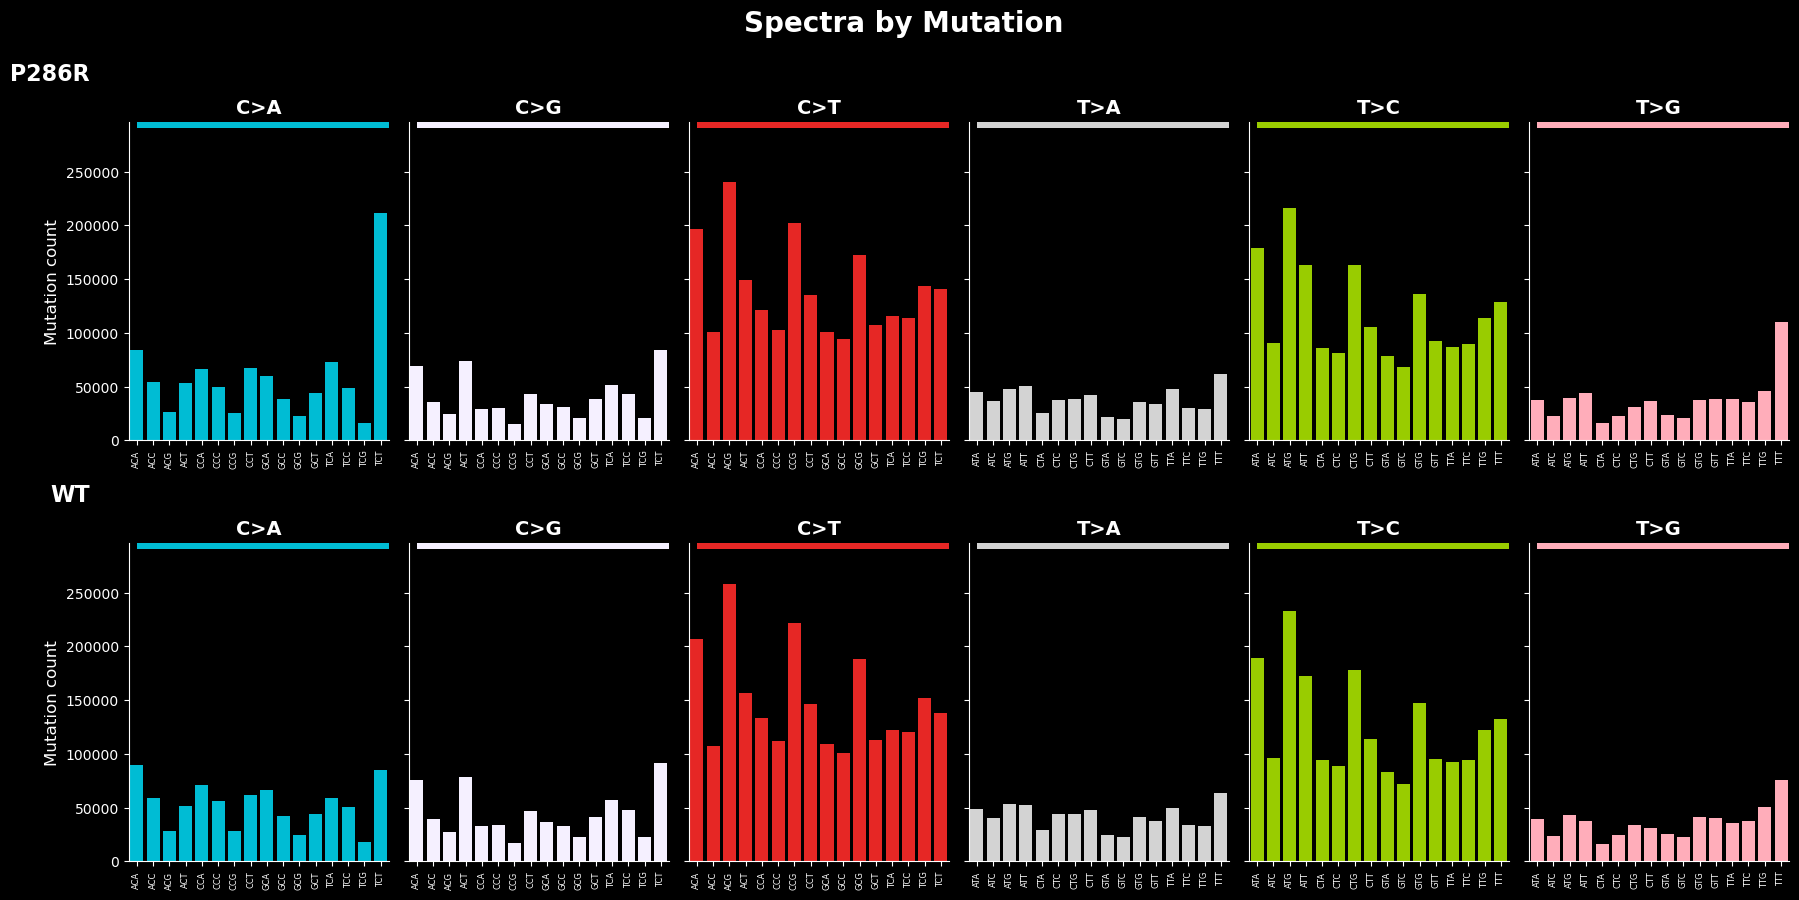

In [16]:
spc.pl.spectrum(adata, groupby='Mutation', figsize=(18,9), palette='dark', transparent=True,
                # outdir='../results/K562_mut_accumulation/'
               )


# Signature Decomposition

### Grouped

In [18]:
spc.tl.fit_cosmic_signatures(adata, groupby='Mutation', output_dir='../results/K562_mut_accumulation/sigprofiler')

Fitting COSMIC v3.4 signatures to spectrum 'spectrum'...
Aggregating spectrum by 'Mutation' using sum...
Created 2 aggregated samples from 2 unique groups
SigProfiler outputs will be saved to: ../results/K562_mut_accumulation/sigprofiler
Converted spectrum to SigProfiler format: ../results/K562_mut_accumulation/sigprofiler/input/matrix.txt
Analyzing 2 samples with 14097759 total mutations
Running SigProfilerAssignment (this may take a few minutes)...
Assigning COSMIC sigs or Signature Database ...... 





                                        ################ Sample 1 #################
############################# Initial Composition #################################### 
       SBS1     SBS2  SBS3  SBS4       SBS5  SBS6    SBS7a  SBS7b  SBS7c  \
0  472532.0  39219.0   0.0   0.0  1836511.0   0.0  10032.0    0.0    0.0   

    SBS7d  ...  SBS90  SBS91  SBS92  SBS93  SBS94  SBS95     SBS96    SBS97  \
0  4989.0  ...    0.0    0.0    0.0    0.0    0.0    0.0  185822.0  58350.0   

    

[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:   12.3s finished




 
Your Job Is Successfully Completed! Thank You For Using SigProfilerAssignment.
 
Parsing results...
Found 47 active signatures across 2 samples
Results stored in:
  - adata.uns['spectrum_Mutation_cosmic_fit']
  - adata.uns['spectrum_Mutation_cosmic_fit_proportions']
  - adata.uns['spectrum_Mutation_cosmic_fit_metadata']
  - adata.uns['cosmic_signatures']


In [10]:
adata.uns['spectrum_Mutation_cosmic_fit_proportions'].loc['P286R'].sort_values(ascending=False)[:15]

SBS5      0.265398
SBS37     0.079594
SBS1      0.068287
SBS54     0.063784
SBS39     0.050480
SBS32     0.047734
SBS46     0.037358
SBS8      0.035758
SBS44     0.034811
SBS89     0.032302
SBS10a    0.027844
SBS96     0.026854
SBS87     0.022153
SBS30     0.022075
SBS40b    0.020708
Name: P286R, dtype: float64

### Individual

In [11]:
spc.tl.fit_cosmic_signatures(adata, output_dir='../results/K562_mut_accumulation/sigprofiler_ind')

Fitting COSMIC v3.4 signatures to spectrum 'spectrum'...
SigProfiler outputs will be saved to: ../results/K562_mut_accumulation/sigprofiler_ind
Converted spectrum to SigProfiler format: ../results/K562_mut_accumulation/sigprofiler_ind/input/matrix.txt
Analyzing 17 samples with 14097759 total mutations
Running SigProfilerAssignment (this may take a few minutes)...
Assigning COSMIC sigs or Signature Database ...... 





                                        ################ Sample 1 #################
############################# Initial Composition #################################### 
      SBS1    SBS2  SBS3  SBS4      SBS5     SBS6   SBS7a  SBS7b  SBS7c  \
0  50867.0  4210.0   0.0   0.0  198111.0  14635.0  2379.0    0.0    0.0   

   SBS7d  ...  SBS90  SBS91  SBS92  SBS93  SBS94  SBS95    SBS96   SBS97  \
0    0.0  ...    0.0    0.0    0.0    0.0    0.0    0.0  19061.0  8383.0   

    SBS98  SBS99  
0  4308.0    0.0  

[1 rows x 86 columns]
L2%:  0.05902456177080947
##############

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:  1.8min
[Parallel(n_jobs=1)]: Done  17 out of  17 | elapsed:  1.8min finished




 
Your Job Is Successfully Completed! Thank You For Using SigProfilerAssignment.
 
Parsing results...
Found 54 active signatures across 17 samples
Results stored in:
  - adata.obsm['spectrum_cosmic_fit']
  - adata.obsm['spectrum_cosmic_fit_proportions']
  - adata.uns['spectrum_cosmic_fit_metadata']
  - adata.uns['cosmic_signatures']


In [12]:
## Plot SBS10a counts of individuals

# Mutation Accumulation

In [44]:
adata_10a = adata[:,adata.var['trinuc_type']=='TCT>TAT'].copy()

In [45]:
lineages = {
    'P286R_C4': ["PolE_Clone_4_P1","PolE_Clone_4_P2","PolE_Clone_4_P3"],
    'P286R_C5': ["PolE_Clone_5_P1","PolE_Clone_5_P2"],
    'P286R_C6': ["PolE_Clone_6_P1","PolE_Clone_6_P2","PolE_Clone_6_P3"],
    'WT_C4': ["AAVS_Clone_4_P1","AAVS_Clone_4_P2","AAVS_Clone_4_P3"],
    'WT_C5': ["AAVS_Clone_5_P1","AAVS_Clone_5_P2","AAVS_Clone_5_P3"],
    'WT_C6': ["AAVS_Clone_6_P1","AAVS_Clone_6_P2","AAVS_Clone_6_P3"],
}

In [46]:
def compute_accumulated_mutations(adata, lineages):
    """
    Compute accumulated mutations along lineage branches.
    
    Parameters
    ----------
    adata : AnnData
        AnnData object with genotype calls in .X (>0 = variant present)
    lineages : dict
        Dictionary mapping lineage names to lists of sample names, ordered by generation.
        The first sample is treated as G0/ancestor.
        e.g., {'P270R_P1': ['Pole-1_P0', 'Pole-1_P1G1', 'Pole-1_P1G2', 'Pole-1_P1G3']}
    
    Returns
    -------
    pd.DataFrame
        DataFrame with columns: Lineage, Split, Samples, Shared_Variants, Accumulated_Mutations
    """
    results = []
    
    for lineage_name, samples in lineages.items():
        samples = list(samples)
        
        # Each split point: from that generation onward
        split_points = []
        for i in range(len(samples)):
            remaining = samples[i:]
            split_points.append((i, remaining))
        
        # Compute shared variant counts
        shared_counts = {}
        sample_labels = {}
        for split_num, sample_set in split_points:
            subset = adata[sample_set, :]
            n_shared = np.ravel((subset.X > 0).sum(axis=0) == len(sample_set)).sum()
            shared_counts[split_num] = n_shared
            sample_labels[split_num] = sample_set
        
        # Compute accumulated (delta from baseline, which is split 0)
        baseline = shared_counts[0]
        for split_num in sorted(shared_counts.keys()):
            results.append({
                'Lineage': lineage_name,
                'Split': split_num,
                'Samples': sample_labels[split_num],
                'Shared_Variants': shared_counts[split_num],
                'Accumulated_Mutations': shared_counts[split_num] - baseline
            })
    
    return pd.DataFrame(results)

In [47]:
time_series = compute_accumulated_mutations(adata_10a, lineages)
time_series = time_series.assign(
    Clone=lambda x: x['Lineage'].str.split('_').str[1],
    Genotype=lambda x: x['Lineage'].str.split('_').str[0]
)

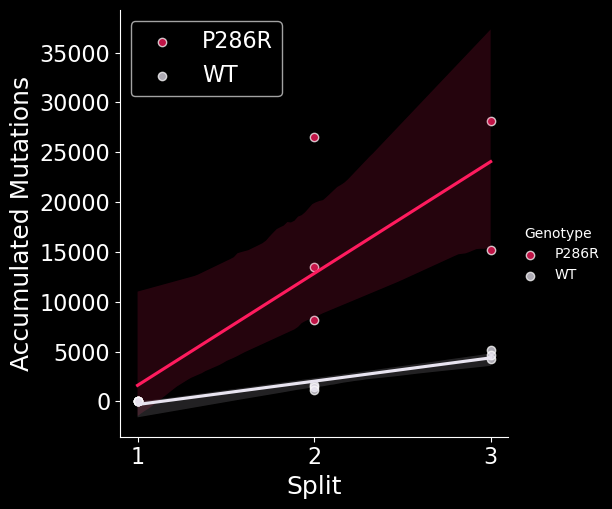

In [57]:
## Plot
g = sns.lmplot(time_series, x='Split',y='Accumulated_Mutations',
               scatter_kws={'ec':'white', 'alpha':0.75},
           palette={'WT':'#E8E4F0','P286R':'#FF1B5E'},
           hue='Genotype'
        )

new_ticks = [0,1,2]
new_labels = ['1','2','3']
g.set(xticks=new_ticks, xticklabels=new_labels)
g.ax.tick_params(labelsize=16)

g.ax.legend(fontsize=16)
# or to also control the title:
leg = g.ax.get_legend()
leg._legend_title_fontsize = 16
for text in leg.get_texts():
    text.set_fontsize(16)

# plt.ylim(-19000,100000)
plt.xlabel("Split", fontsize=18)
plt.ylabel("Accumulated Mutations", fontsize=18)
# plt.setp(g.spines.values(), linewidth=3)
g.savefig('../results/K562_mut_accumulation/10a_accumulation.png', transparent=True, bbox_inches='tight')
plt.show()

# Plot signatures for presentation

In [40]:
spc.pl.spectrum_from_df(adata.uns['cosmic_signatures'].loc['SBS1'], palette='dark', transparent=True,
                        title='SBS1',
                        outpath='../../plots/SBS1.png'
                       )

In [34]:
spc.pl.spectrum_from_df(adata.uns['cosmic_signatures'].loc['SBS4'], palette='dark', transparent=True,
                        title='SBS4',
                        outpath='../../plots/SBS4.png'
                       )

In [41]:
spc.pl.spectrum_from_df(adata.uns['cosmic_signatures'].loc['SBS5'], palette='dark', transparent=True,
                        title='SBS5',
                        outpath='../../plots/SBS5.png'
                       )

In [37]:
spc.pl.spectrum_from_df(adata.uns['cosmic_signatures'].loc['SBS7a'], palette='dark', transparent=True,
                        title='SBS7a',
                        outpath='../../plots/SBS7a.png'
                       )

In [42]:
spc.pl.spectrum_from_df(adata.uns['cosmic_signatures'].loc['SBS10a'], palette='dark', transparent=True,
                        title='SBS10a',
                        outpath='../../plots/SBS10a.png'
                       )

In [43]:
spc.pl.spectrum_from_df(adata.uns['cosmic_signatures'].loc['SBS10b'], palette='dark', transparent=True,
                        title='SBS10b',
                        outpath='../../plots/SBS10b.png'
                       )